In [1]:
import sys
print(sys.executable)

c:\Users\Alvin\anaconda3\python.exe


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
Num GPUs Available: 0


In [3]:
# Then import the required libraries
import importlib
import numpy as np
import os
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
# Remove standalone keras imports and use tf.keras instead
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# Update keras imports to use tf.keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
# Use tf.keras.models instead
from sklearn.model_selection import GridSearchCV
import joblib

In [4]:
#all genes

Input dimensions: 21101
Number of classes: 5
Starting hyperparameter search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END nn__batch_size=16, nn__model__activation=tanh, nn__model__dropout_rate1=0.1, nn__model__dropout_rate2=0.3, nn__model__learning_rate=0.0001;, score=(train=1.000, test=0.585) total time=  37.7s
[CV 2/5] END nn__batch_size=16, nn__model__activation=tanh, nn__model__dropout_rate1=0.1, nn__model__dropout_rate2=0.3, nn__model__learning_rate=0.0001;, score=(train=1.000, test=0.766) total time=  37.3s
[CV 3/5] END nn__batch_size=16, nn__model__activation=tanh, nn__model__dropout_rate1=0.1, nn__model__dropout_rate2=0.3, nn__model__learning_rate=0.0001;, score=(train=1.000, test=0.711) total time=  53.0s
[CV 4/5] END nn__batch_size=16, nn__model__activation=tanh, nn__model__dropout_rate1=0.1, nn__model__dropout_rate2=0.3, nn__model__learning_rate=0.0001;, score=(train=1.000, test=0.572) total time=  59.2s
[CV 5/5] END nn__batch_size=16, nn__mod

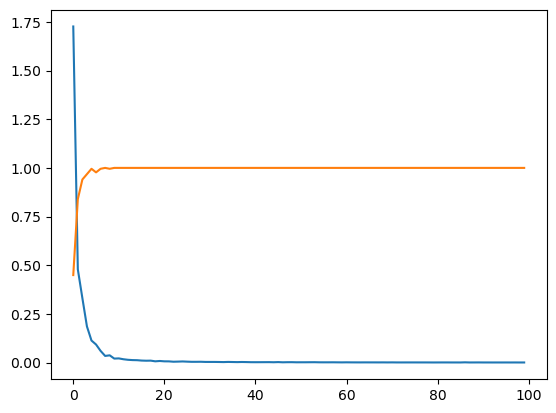


Classification Report:
              precision    recall  f1-score   support

       Basal       0.75      0.86      0.80         7
        Her2       0.67      0.57      0.62         7
        LumA       0.63      1.00      0.77        24
        LumB       1.00      0.08      0.15        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.65        54
   macro avg       0.61      0.50      0.47        54
weighted avg       0.69      0.65      0.56        54



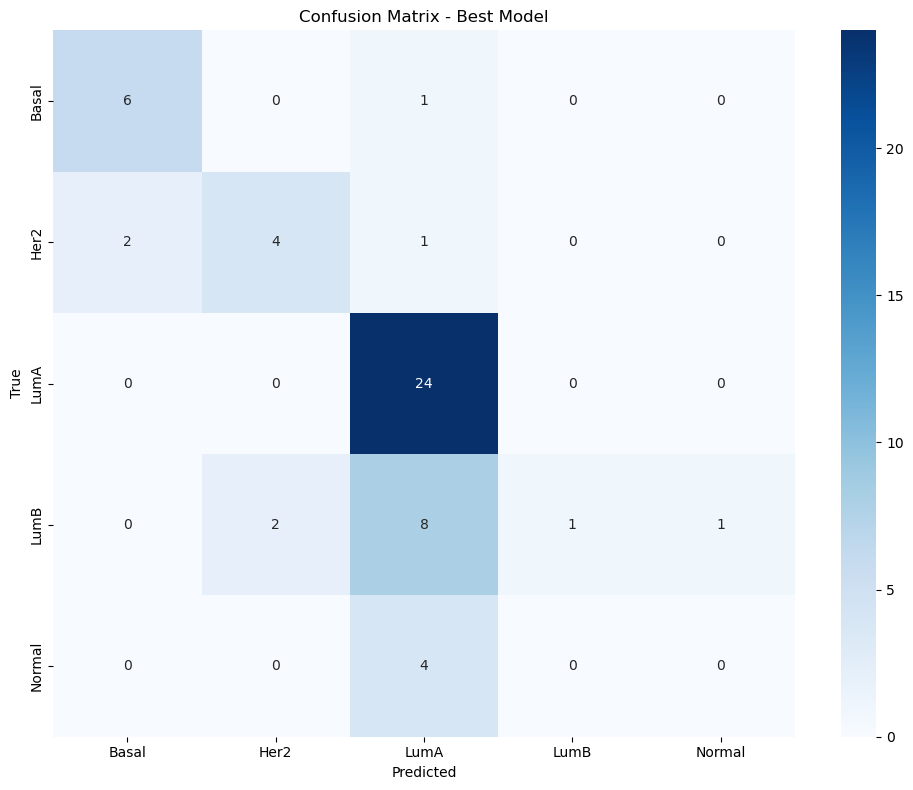


TOP 10 CONFIGURATIONS:

Rank 1:
  Accuracy: 0.7014 (+/- 0.0742)
  Parameters: {'nn__model__learning_rate': 0.001, 'nn__model__dropout_rate2': 0.1, 'nn__model__dropout_rate1': 0.1, 'nn__model__activation': <LeakyReLU name=leaky_re_lu, built=True>, 'nn__batch_size': 32}

Rank 2:
  Accuracy: 0.6945 (+/- 0.0474)
  Parameters: {'nn__model__learning_rate': 0.002, 'nn__model__dropout_rate2': 0.4, 'nn__model__dropout_rate1': 0.2, 'nn__model__activation': <LeakyReLU name=leaky_re_lu, built=True>, 'nn__batch_size': 16}

Rank 3:
  Accuracy: 0.6877 (+/- 0.0777)
  Parameters: {'nn__model__learning_rate': 0.001, 'nn__model__dropout_rate2': 0.2, 'nn__model__dropout_rate1': 0.3, 'nn__model__activation': <LeakyReLU name=leaky_re_lu, built=True>, 'nn__batch_size': 32}

Rank 4:
  Accuracy: 0.6834 (+/- 0.0754)
  Parameters: {'nn__model__learning_rate': 0.002, 'nn__model__dropout_rate2': 0.2, 'nn__model__dropout_rate1': 0.3, 'nn__model__activation': <LeakyReLU name=leaky_re_lu, built=True>, 'nn__batch_siz

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import pandas as pd
import joblib

class HistoryLogger(tf.keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        # This will stay attached to the model after RandomizedSearchCV finishes
        self.model.final_history = self.model.history.history

seed = 0
np.random.seed(seed)

# Split data FIRST
X_train = pd.read_csv("../../Datasets/X_train_Norway_purified.csv").values
X_test = pd.read_csv("../../Datasets/X_test_Norway_purified.csv").values
y_train = pd.read_csv("../../Datasets/y_train_Norway_purified.csv").values.ravel()
y_test = pd.read_csv("../../Datasets/y_test_Norway_purified.csv").values.ravel()

# Label encode
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Get number of classes and input dimension
n_classes = len(np.unique(y_train_enc))
input_dim = X_train.shape[1]

print(f"Input dimensions: {input_dim}")
print(f"Number of classes: {n_classes}")

# Create function to build neural network with more options
def create_nn(meta, neurons_layer1=256, neurons_layer2=128, dropout_rate1=0.3, dropout_rate2=0.3, 
              learning_rate=0.002, activation='relu'):


    # Get input dimensions from meta
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    
    # Build model
    model = Sequential([
        Input(shape=(n_features_in,)),  
        Dense(neurons_layer1, activation=activation),
        BatchNormalization(),
        Dropout(dropout_rate1),
        Dense(neurons_layer2, activation=activation),
        BatchNormalization(),
        Dropout(dropout_rate2),
        Dense(n_classes, activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap model
nn_model = KerasClassifier(
    model=create_nn, 
    epochs=100, 
    verbose=0,
    random_state=seed,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True), HistoryLogger() ]
)

# Pipeline with feature selection
pipeline = ImbPipeline([
    ('nn', nn_model)
])

# Parameter grid based on the paper
param_grid = {
    # Best from paper: None, ReLU, 0.002, 16, 0.3
    'nn__model__activation': ['relu', 'tanh', LeakyReLU(negative_slope=0.01)],
    'nn__model__learning_rate': [0.01, 0.002, 0.001, 0.0001],
    'nn__batch_size': [16, 32, 64],
    'nn__model__dropout_rate1': [0.1, 0.2, 0.3],
    'nn__model__dropout_rate2': [0.1, 0.2, 0.3, 0.4, 0.5]
}

# Use RandomizedSearchCV to sample combinations
print("Starting hyperparameter search...")

start_time = time.time()

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=50,  # Test 50 random combinations
    cv=cv_strat,    
    scoring='f1_weighted',
    n_jobs=1,  # Use 1 to avoid issues with Keras
    verbose=3,  # Maximum verbosity for progress tracking
    random_state=seed,
    return_train_score=True
)

# Fit with progress tracking
random_search.fit(X_train, y_train_enc)

end_time = time.time()
elapsed_time = (end_time - start_time) / 60  # Convert to minutes

# Results
print("\n" + "="*80)
print("SEARCH COMPLETE!")
print("="*80)
print(f"\nTotal time: {elapsed_time:.2f} minutes")
print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation score: {random_search.best_score_:.4f}")

# Test on held-out test set
test_acc = random_search.score(X_test, y_test_enc)
print(f"Test set Score: {test_acc:.4f}")


best_model = random_search.best_estimator_
keras_wrapper = best_model.named_steps['nn']
# Scikeras stores the trained model in .model_
final_history = keras_wrapper.model_.final_history


joblib.dump(best_model, "NN_Norway_RS_Purified_bestmodel.pkl")
print("Best estimator saved to 'NN_Norway_RS_Purified_best_model.pkl'")

plt.plot(final_history['loss'], label='Loss')
plt.plot(final_history['accuracy'], label='Accuracy')
plt.show()

# Predict class labels
y_pred_classes = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.show()


# Create results dataframe
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

# Show top 10 configurations
print("\n" + "="*80)
print("TOP 10 CONFIGURATIONS:")
print("="*80)
top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
for idx, row in top_10.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Accuracy: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Parameters: {row['params']}")


In [6]:

#YOU CAN DELETE THIS I FIXED IT ABOVE JUST RAN AGAIN BECAUSE OF PREVIOUS ERROR 
# import matplotlib.pyplot as plt

# final_history = keras_wrapper.model_.final_history
# plt.plot(final_history['loss'], label='Loss')
# plt.plot(final_history['accuracy'], label='Accuracy')
# plt.show()

# Predict class labels
# y_pred_classes = best_model.predict(X_test)

# print("\nClassification Report:")
# print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# # Confusion matrix
# cm = confusion_matrix(y_test_enc, y_pred_classes)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix - Best Model')
# plt.tight_layout()
# plt.show()


# Create results dataframe
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df = results_df.sort_values('rank_test_score')

# Show top 10 configurations
# print("\n" + "="*80)
# print("TOP 10 CONFIGURATIONS:")
# print("="*80)
# top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
# for idx, row in top_10.iterrows():
#     print(f"\nRank {int(row['rank_test_score'])}:")
#     print(f"  Accuracy: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
#     print(f"  Parameters: {row['params']}")



Test Score (Best Neural Network): 0.5617

Classification Report (Best Neural Network):
              precision    recall  f1-score   support

       Basal       0.75      0.86      0.80         7
        Her2       0.67      0.57      0.62         7
        LumA       0.63      1.00      0.77        24
        LumB       1.00      0.08      0.15        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.65        54
   macro avg       0.61      0.50      0.47        54
weighted avg       0.69      0.65      0.56        54



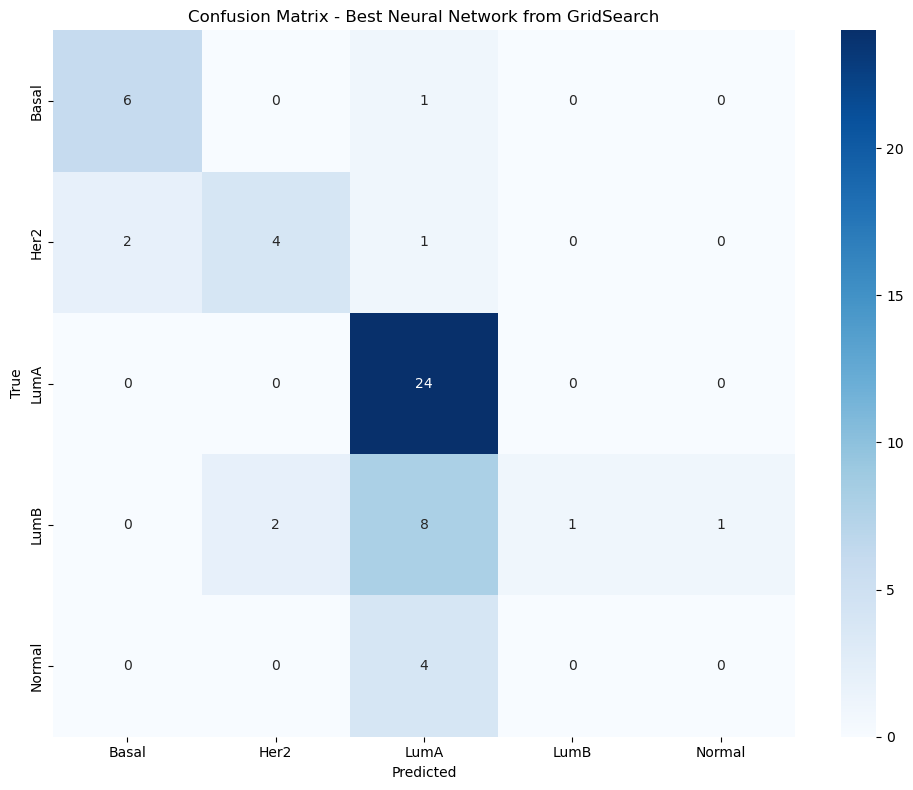

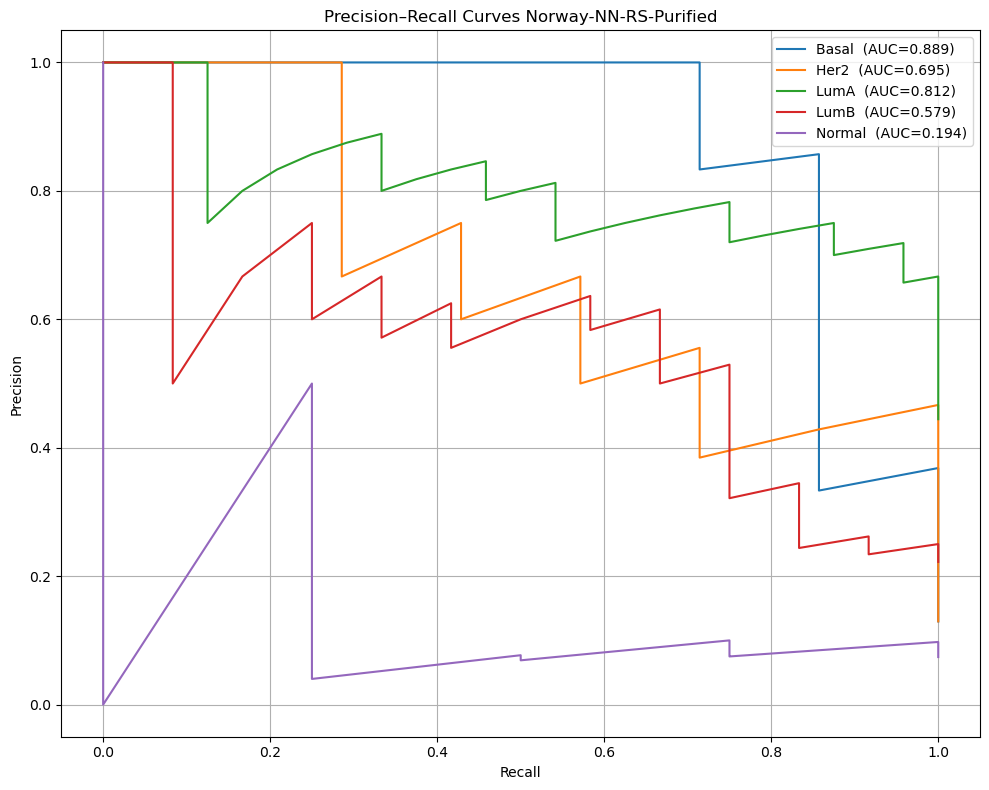

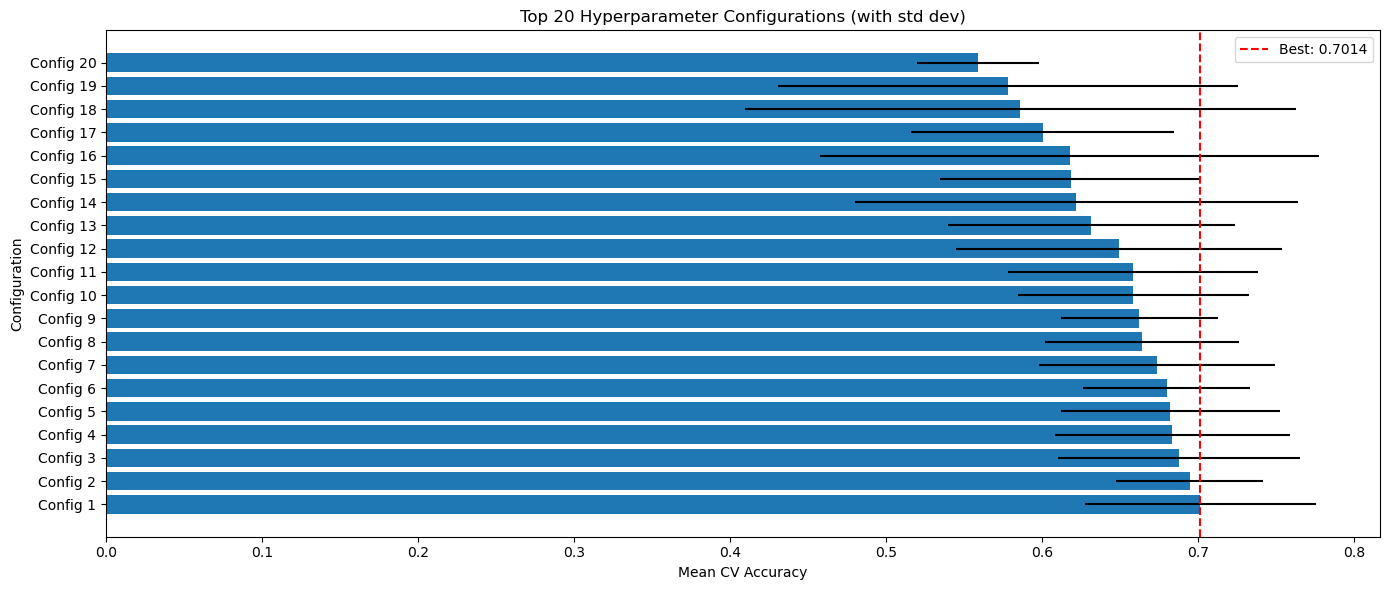


HYPERPARAMETER ANALYSIS:

nn__model__activation:
  <LeakyReLU name=leaky_re_lu, built=True>: appears 7/10 times in top 10
  tanh: appears 2/10 times in top 10
  relu: appears 1/10 times in top 10

nn__model__learning_rate:
  0.001: appears 4/10 times in top 10
  0.0001: appears 3/10 times in top 10
  0.002: appears 2/10 times in top 10
  0.01: appears 1/10 times in top 10

nn__batch_size:
  16: appears 6/10 times in top 10
  32: appears 3/10 times in top 10
  64: appears 1/10 times in top 10

nn__model__dropout_rate1:
  0.1: appears 4/10 times in top 10
  0.2: appears 3/10 times in top 10
  0.3: appears 3/10 times in top 10

nn__model__dropout_rate2:
  0.1: appears 3/10 times in top 10
  0.4: appears 2/10 times in top 10
  0.2: appears 2/10 times in top 10
  0.3: appears 2/10 times in top 10
  0.5: appears 1/10 times in top 10


C:\Users\Alvin\AppData\Local\Temp\ipykernel_23360\3734401464.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])


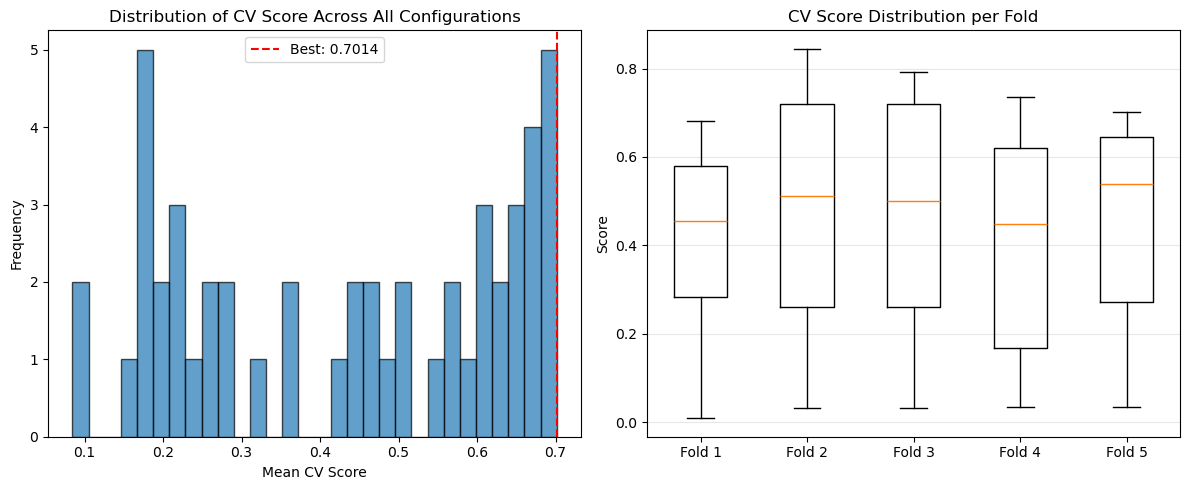


SUMMARY STATISTICS:
Best CV Score: 0.7014
Test Score: 0.5617
Mean CV Score (all configs): 0.4365
Std CV Score (all configs): 0.2033
Min CV Score: 0.0843
Max CV Score: 0.7014


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve ,average_precision_score
from sklearn.preprocessing import label_binarize
import pandas as pd
from collections import Counter

# Evaluate on test set using best model from grid search
test_acc = random_search.score(X_test, y_test_enc)
print(f"\nTest Score (Best Neural Network): {test_acc:.4f}")

# Predict using best model
y_pred_classes = random_search.predict(X_test)
y_pred_proba = random_search.predict_proba(X_test)

# Classification report
print("\nClassification Report (Best Neural Network):")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Best Neural Network from GridSearch')
plt.tight_layout()
plt.show()


# PRECISION–RECALL CURVE
# -------------------------------
# Convert predictions into the max probability for each sample
y_score = np.max(y_pred_proba, axis=1)

# Convert true labels to 1 if correct, 0 otherwise
y_test_binarized = label_binarize(y_test_enc, classes=range(len(le.classes_)))

plt.figure(figsize=(10, 8))


for i, class_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    auc_score = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f"{class_name}  (AUC={auc_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves Norway-NN-RS-Purified")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
#  Results Visualization
# ------------------------------------------------------------------

results_df = pd.DataFrame(random_search.cv_results_)

# Plot top 20 configurations
plt.figure(figsize=(14, 6))
top_20 = results_df.nsmallest(20, 'rank_test_score')

plt.barh(range(len(top_20)), top_20['mean_test_score'], xerr=top_20['std_test_score'])
plt.yticks(range(len(top_20)), [f"Config {i+1}" for i in range(len(top_20))])
plt.xlabel('Mean CV Accuracy')
plt.ylabel('Configuration')
plt.title('Top 20 Hyperparameter Configurations (with std dev)')
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', label=f'Best: {random_search.best_score_:.4f}')
plt.legend()
plt.tight_layout()
plt.show()



# ------------------------------------------------------------------
# Hyperparameter importance analysis
# ------------------------------------------------------------------

print("\n" + "="*80)
print("HYPERPARAMETER ANALYSIS:")
print("="*80)

top_10_configs = results_df.nsmallest(10, 'rank_test_score')

for param in ['nn__model__activation', 
              'nn__model__learning_rate', 'nn__batch_size', 'nn__model__dropout_rate1', 'nn__model__dropout_rate2']:
    print(f"\n{param}:")
    param_values = [config[param] for config in top_10_configs['params']]
    counts = Counter(param_values)
    for value, count in counts.most_common():
        print(f"  {value}: appears {count}/10 times in top 10")

# ------------------------------------------------------------------
# CV Accuracy Distribution
# ------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Histogram of all CV accuracies
plt.subplot(1, 2, 1)
plt.hist(results_df['mean_test_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', 
            label=f'Best: {random_search.best_score_:.4f}')
plt.xlabel('Mean CV Score')
plt.ylabel('Frequency')
plt.title('Distribution of CV Score Across All Configurations')
plt.legend()

# Box plot (adjust to number of folds)
plt.subplot(1, 2, 2)
n_folds = random_search.cv.n_splits  # dynamically use actual folds
cv_scores = [results_df[f'split{i}_test_score'] for i in range(n_folds)]
plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])
plt.ylabel('Score')
plt.title('CV Score Distribution per Fold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------

print("\n" + "="*80)
print("SUMMARY STATISTICS:")
print("="*80)
print(f"Best CV Score: {random_search.best_score_:.4f}")
print(f"Test Score: {test_acc:.4f}")
print(f"Mean CV Score (all configs): {results_df['mean_test_score'].mean():.4f}")
print(f"Std CV Score (all configs): {results_df['mean_test_score'].std():.4f}")
print(f"Min CV Score: {results_df['mean_test_score'].min():.4f}")
print(f"Max CV Score: {results_df['mean_test_score'].max():.4f}")


In [8]:
# If you used a Scikeras wrapper
print("\nBest Keras model parameters:")
print(best_model.get_params())


Best Keras model parameters:
{'memory': None, 'steps': [('nn', KerasClassifier(
	model=<function create_nn at 0x00000259251945E0>
	build_fn=None
	warm_start=False
	random_state=0
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x0000025F3E484F30>, <__main__.HistoryLogger object at 0x0000025F4EDB9070>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=100
	class_weight=None
	model__learning_rate=0.001
	model__dropout_rate2=0.1
	model__dropout_rate1=0.1
	model__activation=<LeakyReLU name=leaky_re_lu, built=True>
))], 'transform_input': None, 'verbose': False, 'nn': KerasClassifier(
	model=<function create_nn at 0x00000259251945E0>
	build_fn=None
	warm_start=False
	random_state=0
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000002

In [9]:
import shap
import lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# SETTINGS
# ==========================================
MAX_BACKGROUND = 10
MAX_EXPLAIN = 50
SHAP_BATCH_SIZE = 32
RANDOM_STATE = 42
TOP_K = 10

OUT_DIR = "./explain_results"
os.makedirs(OUT_DIR, exist_ok=True)

# ==========================================
# EXTRACT BEST KERAS MODEL FROM HYPERPARAM SEARCH
# ==========================================
# Example: grid_search is your sklearn/Scikeras search object
# It should have attribute best_estimator_
best_model = random_search.best_estimator_

# If it's a Scikeras wrapper, extract the underlying Keras model
keras_model = getattr(best_model, "model_", None)
if keras_model is None:
    try:
        keras_model = best_model.named_steps['nn'].model_
    except Exception:
        keras_model = best_model  # fallback: raw Keras model

print("Using Keras model from hyperparameter search:", type(keras_model))

# ==========================================
# WRAPPER FOR REDUCED FEATURES
# ==========================================
X_mean = X_train_arr.mean(axis=0)

def model_wrapper(X_reduced):
    """Map reduced features back to full model input for Keras."""
    X_full = np.tile(X_mean, (X_reduced.shape[0], 1))
    X_full[:, keep_idx] = X_reduced
    return keras_model.predict(X_full)

# ==========================================
# SHAP EXPLANATIONS
# ==========================================
print("\n[SHAP] Generating explanations...")

small_bg = shap.sample(X_train_reduced, min(MAX_BACKGROUND, X_train_reduced.shape[0]), random_state=RANDOM_STATE)
small_test = shap.sample(X_test_reduced, min(MAX_EXPLAIN, X_test_reduced.shape[0]), random_state=RANDOM_STATE)

# Attempt DeepExplainer first
try:
    explainer = shap.DeepExplainer(keras_model, small_bg)
    use_wrapper = False
    print("Using DeepExplainer for Keras model.")
except Exception:
    explainer = shap.Explainer(model_wrapper, small_bg)
    use_wrapper = True
    print("DeepExplainer not supported, using generic Explainer.")

# Compute SHAP values
if use_wrapper:
    shap_exp = explainer(small_test)
else:
    shap_exp = explainer(small_test)

shap_values = shap_exp.values  # shape: (samples, features) or (samples, features, classes)
expected_value = shap_exp.base_values

# ==========================================
# HANDLE SHAP OUTPUT FORMATS
# ==========================================
if isinstance(shap_values, list):
    shap_values = np.stack([np.array(s) for s in shap_values], axis=2)  # (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(kept_feature_names)}")

# ==========================================
# 1. OVERALL SHAP IMPORTANCE (max across classes)
# ==========================================
if shap_values.ndim == 3:
    shap_values_overall = np.abs(shap_values).max(axis=2)  # max importance per sample across classes
else:
    shap_values_overall = np.abs(shap_values)

mean_abs_shap_overall = shap_values_overall.mean(axis=0)

shap_importances_overall = pd.DataFrame({
    "Feature": kept_feature_names,
    "MeanAbsSHAP_MaxAcrossClasses": mean_abs_shap_overall
}).sort_values(by="MeanAbsSHAP_MaxAcrossClasses", ascending=False)

# Top 10
top_features_overall = shap_importances_overall.head(TOP_K)
top_features_overall.to_csv(os.path.join(OUT_DIR, "top_features_overall_max.csv"), index=False)

print("\n=== Overall Top 10 Features (max across classes) ===")
print(top_features_overall)

# --- Bar plot ---
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features_overall,
    x="MeanAbsSHAP_MaxAcrossClasses",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features (Overall, Max Across Classes)")
plt.xlabel("Mean |SHAP| Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top10_overall_bar.png"), dpi=150)
plt.close()

# --- SHAP summary plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall,
    small_test,
    feature_names=kept_feature_names,
    max_display=TOP_K,
    show=False,
    color_bar=False
)
plt.title("Overall SHAP Summary (Max Importance per Class)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "summary_overall.png"), dpi=150)
plt.close()

# ==========================================
# 2. PER-CLASS SHAP IMPORTANCE
# ==========================================
# Ensure proper class names from LabelEncoder
if shap_values.ndim == 3:
    n_classes = shap_values.shape[2]
    
    # Use actual class names if LabelEncoder is available
    if 'le' in globals() and hasattr(le, 'classes_'):
        class_names = le.classes_
    else:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    for class_idx, class_name in enumerate(class_names):
        print(f"\n{'='*70}")
        print(f"Class {class_idx+1}: {class_name}")
        print(f"{'='*70}")

        shap_values_class = shap_values[:, :, class_idx]
        mean_abs_class = np.abs(shap_values_class).mean(axis=0)

        shap_importances_class = pd.DataFrame({
            "Feature": kept_feature_names,
            "MeanAbsSHAP": mean_abs_class
        }).sort_values(by="MeanAbsSHAP", ascending=False)

        top_features_class = shap_importances_class.head(TOP_K)
        top_features_class.to_csv(os.path.join(OUT_DIR, f"top_features_{class_name}.csv"), index=False)

        print(top_features_class)

        # Summary plot per class
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_values_class,
            small_test,
            feature_names=kept_feature_names,
            max_display=TOP_K,
            show=False,
            color_bar=False
        )
        plt.title(f"SHAP Summary - {class_name}")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"summary_{class_name}.png"), dpi=150)
        plt.close()

        # Bar plot per class
        plt.figure(figsize=(10, 8))
        sns.barplot(
            data=top_features_class,
            x="MeanAbsSHAP",
            y="Feature",
            palette="Greens_d"
        )
        plt.title(f"Top 10 SHAP Features - {class_name}")
        plt.xlabel("Mean |SHAP| Value")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"top10_{class_name}_bar.png"), dpi=150)
        plt.close()

print("\n✅ SHAP analysis complete — using best Keras model from hyperparameter search.")


Using Keras model from hyperparameter search: <class 'keras.src.models.sequential.Sequential'>


NameError: name 'X_train_arr' is not defined

In [ ]:
# Ensure proper class names from LabelEncoder
if shap_values.ndim == 3:
    n_classes = shap_values.shape[2]
    
    # Use actual class names if LabelEncoder is available
    if 'le' in globals() and hasattr(le, 'classes_'):
        class_names = le.classes_
    else:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    for class_idx, class_name in enumerate(class_names):
        print(f"\n{'='*70}")
        print(f"Class {class_idx+1}: {class_name}")
        print(f"{'='*70}")

        shap_values_class = shap_values[:, :, class_idx]
        mean_abs_class = np.abs(shap_values_class).mean(axis=0)

        shap_importances_class = pd.DataFrame({
            "Feature": kept_feature_names,
            "MeanAbsSHAP": mean_abs_class
        }).sort_values(by="MeanAbsSHAP", ascending=False)

        top_features_class = shap_importances_class.head(TOP_K)
        top_features_class.to_csv(os.path.join(OUT_DIR, f"top_features_{class_name}.csv"), index=False)

        print(top_features_class)

        # Summary plot per class
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_values_class,
            small_test,
            feature_names=kept_feature_names,
            max_display=TOP_K,
            show=False,
            color_bar=False
        )
        plt.title(f"SHAP Summary - {class_name}")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"summary_{class_name}.png"), dpi=150)
        plt.close()

        # Bar plot per class
        plt.figure(figsize=(10, 8))
        sns.barplot(
            data=top_features_class,
            x="MeanAbsSHAP",
            y="Feature",
            palette="Greens_d"
        )
        plt.title(f"Top 10 SHAP Features - {class_name}")
        plt.xlabel("Mean |SHAP| Value")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"top10_{class_name}_bar.png"), dpi=150)
        plt.close()



Class 1: Basal
         Feature  MeanAbsSHAP
83        SEPT12     0.000008
47     LOC727677     0.000008
7   LOC100130331     0.000007
65          IAPP     0.000007
2          LEMD1     0.000006
87          PIGS     0.000006
4         CHI3L1     0.000006
73         MNAT1     0.000006
12           ZP4     0.000006
93           MIA     0.000006


D:\TEMP\ipykernel_4484\3306662950.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\TEMP\ipykernel_4484\3306662950.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Class 2: Her2
      Feature  MeanAbsSHAP
65       IAPP     0.000204
83     SEPT12     0.000200
47  LOC727677     0.000187
2       LEMD1     0.000179
41      FABP7     0.000159
27  LOC285548     0.000156
87       PIGS     0.000154
6      AXDND1     0.000147
9      HCRTR1     0.000142
4      CHI3L1     0.000138


D:\TEMP\ipykernel_4484\3306662950.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\TEMP\ipykernel_4484\3306662950.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Class 3: LumA
      Feature  MeanAbsSHAP
47  LOC727677     0.000686
65       IAPP     0.000648
83     SEPT12     0.000643
87       PIGS     0.000509
73      MNAT1     0.000502
2       LEMD1     0.000500
4      CHI3L1     0.000459
75     IGFALS     0.000458
34     ZNF366     0.000450
44    IGF2BP3     0.000441


D:\TEMP\ipykernel_4484\3306662950.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\TEMP\ipykernel_4484\3306662950.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Class 4: LumB
      Feature  MeanAbsSHAP
24    PA2G4P4     0.000324
52      MAT1A     0.000322
25     MIR563     0.000305
94    BPIFA4P     0.000296
44    IGF2BP3     0.000280
65       IAPP     0.000277
28       FGF2     0.000240
47  LOC727677     0.000232
66      GGACT     0.000205
79     ABCC11     0.000191


D:\TEMP\ipykernel_4484\3306662950.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\TEMP\ipykernel_4484\3306662950.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Class 5: Normal
         Feature  MeanAbsSHAP
25        MIR563     0.000349
83        SEPT12     0.000291
7   LOC100130331     0.000288
89         EVI2A     0.000279
9         HCRTR1     0.000272
47     LOC727677     0.000265
12           ZP4     0.000262
79        ABCC11     0.000252
2          LEMD1     0.000252
93           MIA     0.000249


D:\TEMP\ipykernel_4484\3306662950.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\TEMP\ipykernel_4484\3306662950.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


In [ ]:
# Align lengths safely
min_len = min(len(kept_feature_names), len(mean_abs))
importance_df = pd.DataFrame({
    'Feature': kept_feature_names[:min_len],
    'SHAP_Importance': mean_abs[:min_len]
}).sort_values('SHAP_Importance', ascending=False)


top_k = min(10, importance_df.shape[0])
top_features = importance_df.head(top_k)
top_features.to_csv(os.path.join(OUT_DIR, 'top_features_shap.csv'), index=False)
print("\nTop SHAP features saved to:", os.path.join(OUT_DIR, 'top_features_shap.csv'))
print(top_features.to_string(index=False))

# Plot SHAP importance
plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'][::-1], top_features['SHAP_Importance'][::-1])
plt.xlabel('Mean |SHAP value|')
plt.title('Top SHAP Features')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'top_features_shap.png'), dpi=150, bbox_inches='tight')
plt.close()

# Optional summary plot
try:
    top_idx = [kept_feature_names.index(f) for f in top_features['Feature'].values]
    shap.summary_plot(shap_values, small_test[:, top_idx], feature_names=[kept_feature_names[i] for i in top_idx], show=False)
    plt.savefig(os.path.join(OUT_DIR, 'shap_summary_top.png'), dpi=150, bbox_inches='tight')
    plt.close()
except Exception as e:
    print("Could not produce summary_plot:", e)

# ------------------------------------------
# LIME EXPLANATIONS
# ------------------------------------------
print("\n[LIME] Generating explanations...")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_reduced,
    feature_names=kept_feature_names,
    mode='classification',
    discretize_continuous=True
)

# Sample instance for explanation
i = np.random.randint(0, X_test_reduced.shape[0])
exp = explainer_lime.explain_instance(
    data_row=X_test_reduced[i],
    predict_fn=lambda x: model_wrapper(x),
    num_features=10
)

lime_path = os.path.join(OUT_DIR, 'lime_explanation.png')
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig(lime_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"LIME explanation saved to: {lime_path}")
print("\n✅ SHAP and LIME explanations completed successfully.")





Top SHAP features saved to: ./explain_results\top_features_shap.csv
 Feature  SHAP_Importance
   LEMD1         0.000215
  CHI3L1         0.000119
    DNM3         0.000081
SH3BGRL3         0.000067
  MIR452         0.000003


D:\TEMP\ipykernel_4484\147470598.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, small_test[:, top_idx], feature_names=[kept_feature_names[i] for i in top_idx], show=False)


Could not produce summary_plot: The shape of the shap_values matrix does not match the shape of the provided data matrix.

[LIME] Generating explanations...
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
LIME explanation saved to: ./explain_results\lime_explanation.png

✅ SHAP and LIME explanations completed successfully.
